# K-NN (KNearst Neighbors) Algorithm

# 0/ Library Imports

In [1]:
"""
Library importation proecess for K-NN
This notebook is self-contained and initializes and installs the necessary libraries for the K-NN algorithm.
"""

# Numpy
%pip install pandas
import pandas as pd

# Sklearn
%pip install scikit-learn
# Import train_test_split function
from sklearn.model_selection import train_test_split
# Import StandardScaler for KNN
from sklearn.preprocessing import StandardScaler
# Import KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_curve, roc_auc_score, brier_score_loss
from sklearn.metrics import ConfusionMatrixDisplay
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Numpy
%pip install numpy
import numpy as np

# Matplotlib
%pip install matplotlib
import matplotlib.pyplot as plt

# Seaborn
%pip install seaborn
import seaborn as sns


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 1/ Dataset Preparation

## 1.1/ Data Loading


In [2]:
"""
Dataset importation process for K-NN
Path to the dataset is '../datasets/all_dataset.csv'
"""

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Import [all_dataset.csv]
df = pd.read_csv('../datasets/all_dataset.csv')

df = df[df['timestamp'] != 0]
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

df.fillna(df.median(), inplace=True)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('winner')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.fillna(df.median(), inplace=True)

# Show the first 15 rows of the dataset
df.head(15)

,timestamp,BLUE.HEXTECH_DRAGON.kills,BLUE.WATER_DRAGON.kills,BLUE.FIRE_DRAGON.kills,BLUE.EARTH_DRAGON.kills,BLUE.AIR_DRAGON.kills,BLUE.CHEMTECH_DRAGON.kills,BLUE.ELDER_DRAGON.kills,BLUE.RIFTHERALD.kills,BLUE.BARON_NASHOR.kills,...,soul_Mountain,soul_Ocean,BLUE.minionRatio,RED.minionRatio,BLUE.totalGoldRatio,RED.totalGoldRatio,BLUE.levelRatio,RED.levelRatio,BLUE.kda,RED.kda
1,0.000004,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.344908,0.333258,0.916031,0.915413,0.033613,0.027848
4,0.046862,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.516207,0.505364,0.101616,0.128358,0.662462,0.788548,0.009804,0.075949
5,0.062477,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.588619,0.569928,0.116130,0.112218,0.662505,0.763289,0.019608,0.037975
6,0.078092,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.593383,0.576440,0.117811,0.116459,0.620325,0.662087,0.022059,0.033755
7,0.093706,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.640869,0.636767,0.117568,0.115568,0.626379,0.589801,0.022059,0.033755
8,0.109323,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.637898,0.660685,0.111410,0.108119,0.567581,0.598834,0.022059,0.033755
9,0.124933,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.683096,0.676618,0.108545,0.113253,0.550038,0.549666,0.017647,0.042194
10,0.140549,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.719229,0.728312,0.115004,0.124769,0.586622,0.535606,0.014706,0.046414
11,0.156160,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.692703,0.715264,0.125650,0.123059,0.524476,0.478102,0.023109,0.032911
12,0.171778,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.676512,0.708429,0.125345,0.113336,0.514873,0.472342,0.027311,0.027426


## 1.2/ Handle missing values and infinities & Data Preprocessing

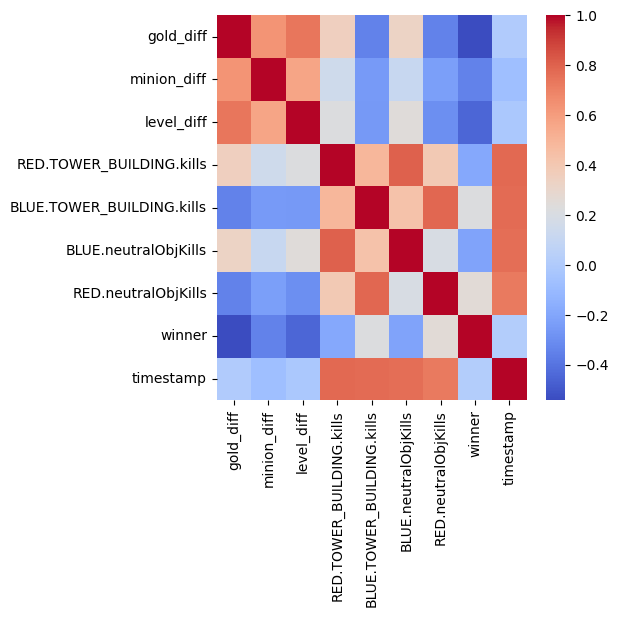

In [3]:
tdf = df.copy()
tdf = tdf.drop(columns=df.columns)
tdf['gold_diff'] = df['BLUE.totalGoldRatio'] - df['RED.totalGoldRatio']
tdf['minion_diff'] = df['BLUE.minionRatio'] - df['RED.minionRatio']
tdf['level_diff'] = df['BLUE.levelRatio'] - df['RED.levelRatio']

tdf['RED.TOWER_BUILDING.kills'] = df['RED.TOWER_BUILDING.kills']
tdf['BLUE.TOWER_BUILDING.kills'] = df['BLUE.TOWER_BUILDING.kills']

tdf["BLUE.neutralObjKills"] = df["BLUE.HEXTECH_DRAGON.kills"] + df["BLUE.WATER_DRAGON.kills"] + \
                                df["BLUE.FIRE_DRAGON.kills"] + df["BLUE.EARTH_DRAGON.kills"] + \
                                df["BLUE.AIR_DRAGON.kills"] + df["BLUE.ELDER_DRAGON.kills"] + \
                                df["BLUE.RIFTHERALD.kills"] + df["BLUE.BARON_NASHOR.kills"] + \
                                df["BLUE.ATAKHAN.kills"] + df["BLUE.CHEMTECH_DRAGON.kills"] + \
                                df["BLUE.HORDE.kills"]

tdf["RED.neutralObjKills"] = df["RED.HEXTECH_DRAGON.kills"] + df["RED.WATER_DRAGON.kills"] + \
                                df["RED.FIRE_DRAGON.kills"] + df["RED.EARTH_DRAGON.kills"] + \
                                df["RED.AIR_DRAGON.kills"] + df["RED.ELDER_DRAGON.kills"] + \
                                df["RED.RIFTHERALD.kills"] + df["RED.BARON_NASHOR.kills"] + \
                                df["RED.ATAKHAN.kills"] + df["RED.CHEMTECH_DRAGON.kills"] + \
                                df["RED.HORDE.kills"]
tdf['winner'] = df['winner']

tdf['timestamp'] = df['timestamp']

correlationMat = tdf.corr()

# Set the size of the plot
plt.figure(figsize=(5, 5))

# Create a heatmap of the correlation matrix
sns.heatmap(correlationMat, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

In [4]:
# Assign the custom dataset to the original dataset
df = tdf

print(df.head(15))

# Count the number of games won by each team
df['winner'].value_counts()

    gold_diff  minion_diff  level_diff  RED.TOWER_BUILDING.kills  \
1    0.011650     0.000000    0.000618                  0.000000   
4   -0.026742     0.010843   -0.126086                  0.000000   
5    0.003912     0.018691   -0.100783                  0.000000   
6    0.001351     0.016943   -0.041762                  0.000000   
7    0.002000     0.004102    0.036578                  0.000000   
8    0.003292    -0.022787   -0.031253                  0.000000   
9   -0.004708     0.006478    0.000371                  0.000000   
10  -0.009766    -0.009083    0.051016                  0.000000   
11   0.002591    -0.022561    0.046373                  0.000000   
12   0.012009    -0.031917    0.042531                  0.000000   
13  -0.009192    -0.038391    0.000316                  0.000000   
14  -0.015723    -0.037024    0.000301                  0.000000   
15  -0.007986    -0.027679    0.000276                  0.058824   
16  -0.004598    -0.018873   -0.015532          

winner
0    3078892
1    2972302
Name: count, dtype: int64

## 1.3/ Target and Features

In [5]:
"""
Define features and target
The target is the 'winner' column
"""

# Define features and target
X = df.drop(columns=["winner"])  # Features
X = X.drop(columns=["timestamp"])
y = df["winner"]  # Target

# Create y_info, which contains both the target (y) and the timestamp
y_info = pd.DataFrame({'timestamp': df['timestamp'], 'winner': y})

# Verify that the target can hold only 2 unique values
assert len(np.unique(y)) == 2

## 1.4/ Train-Test Split

In [ ]:
"""
Split the dataset into training and testing sets
Proportion: 80% training, 20% testing
"""

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_info, test_size=0.2, random_state=42)

# Drop timestamp in training set and testing set
y_train = y_train.drop(columns=['timestamp'])
y_test_with_timestamp = y_test.copy()
y_test = y_test.drop(columns=['timestamp'])

# Print train and test set shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4840955, 7) (1210239, 7) (4840955, 1) (1210239, 1)


## 1.5/ Feature Scaling & Normalization

In [ ]:
"""
Normalize the features using StandardScaler
Required for K-NN
"""

# Normalize features using StandardScaler
scaler = StandardScaler()

# StandardScaler is less sensitive to the presence of outliers
# It scales the data based on the mean and standard deviation

# Normalize training and testing features
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2/ K-NN Algorithm

In [8]:
"""
Initialize and train the K-NN model
Parameters:
- n_neighbors: 5
- n_jobs: -1

This model used 5 neighbors and all available processors for parallel processing.
"""

# Initialize the regressor
knn = KNeighborsRegressor(n_neighbors=10, n_jobs=-1)

# Train the model
knn.fit(X_train, y_train)

KNeighborsRegressor(n_jobs=-1, n_neighbors=10)

# 3/ Model Evaluation

In [9]:
"""
Predict how long it will take to predict the entire test set
This is done by predicting a subset of the test set and extrapolating the time it will take to predict the entire test set.
"""

import time

subset_size = 500  # Small sample for timing

# Start the timer
start_time = time.time()

# Predict the subset
y_pred = knn.predict(X_test[:subset_size])

# Stop the timer
end_time = time.time()

# Compute the estimated time for the full prediction
estimated_time = (end_time - start_time) * (len(X_test) / subset_size)
print(f"Estimated time for full prediction: {estimated_time:.2f} seconds => ({estimated_time / 60:.2f} minutes)")

Estimated time for full prediction: 117.84 seconds => (1.96 minutes)


### 3.1/ Predict using the model

In [10]:
"""
Predict the entire test set
"""

# Predict the entire test set
y_pred = knn.predict(X_test)

### 3.2/ Model Evaluation

********** KNN SCORES **********
Mean Absolute Error (MAE): 0.3031
Mean Squared Error (MSE): 0.1648
Root Mean Squared Error (RMSE): 0.4060
R^2 Score: 0.3404
f1 Score: 0.7301
Precision Score: 0.7685
Recall Score: 0.6953
Brier Score: 0.1648
**********************************
********** KNN ACCURACY **********
Accuracy: 0.7477
**********************************


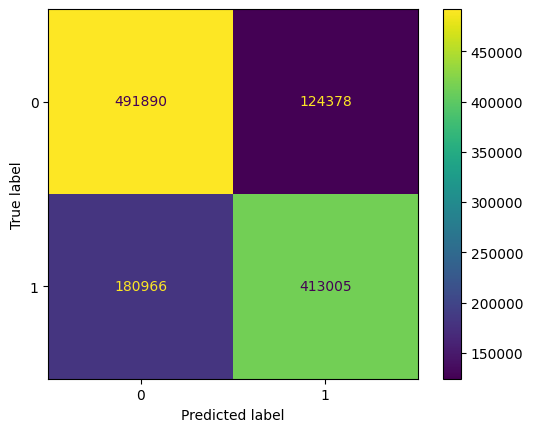

In [11]:
"""
Evaluate the model
Using :
- Mean Absolute Error
- Mean Squared Error
- Root Mean Squared Error
- R^2 Score
- F1 Score
- Precision Score
- Recall Score
"""

# Show statistics
# Evaluate the model using MAE, MSE, RMSE, R^2 Score, F1 score, Precision Score and Recall Score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
brier_score = brier_score_loss(y_test, y_pred)

# Legacy mode (convert probabilities to binary; threshold set to '> 0.5')
y_pred_binary = (y_pred > 0.5).astype(int)
f1 = f1_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)


print("********** KNN SCORES **********")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"f1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"Brier Score: {brier_score:.4f}")
print("**********************************")

# Get the final accuracy and the confusion matrix
accuracy = accuracy_score(y_test, y_pred_binary)
conf_matrix = confusion_matrix(y_test, y_pred_binary)

print("********** KNN ACCURACY **********")
print(f"Accuracy: {accuracy:.4f}")
print("**********************************")

# Plot confusion matrix
cmatrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["0", "1"])
cmatrix_display.plot() 

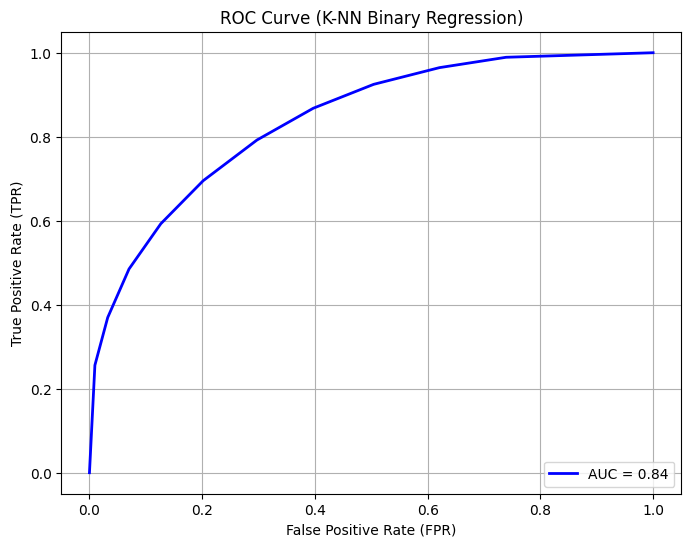

AUC-ROC Score: 0.8384


In [12]:
"""
ROC Curve & AUC-ROC Score
"""

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Compute AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_roc:.2f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (K-NN Binary Regression)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC-ROC score
print(f"AUC-ROC Score: {auc_roc:.4f}")

In [ ]:
"""
Accuracy per timestamp group (5 groups)
"""

assert len(y_test_with_timestamp['timestamp']) == len(y_pred_binary) == len(y_test)

# Store each row
y_pred_info_list = []

for i in range(len(y_test_with_timestamp)):
    timestamp = y_test_with_timestamp['timestamp'].iloc[i]
    y_pred = y_pred_binary[i][0]
    y_true = y_test.iloc[i]['winner']
    y_pred_info_list.append({'timestamp': timestamp, 'y_pred': y_pred, 'y_true': y_true})

# Create a dataframe from the list
y_pred_info = pd.DataFrame(y_pred_info_list)

print(y_pred_info.head(5))

# Create timestamp groups using pd.cut
y_pred_info['timestamp_group'] = pd.cut(y_pred_info['timestamp'], bins=5)

# Store the mean accuracy (overall testing set) in "mean_accuracy"
mean_accuracy = accuracy

   timestamp  y_pred  y_true
0   0.390346       1       0
1   0.015618       0       0
2   0.000001       0       0
3   0.124945       0       0
4   0.374755       0       0


0.7476994213539639


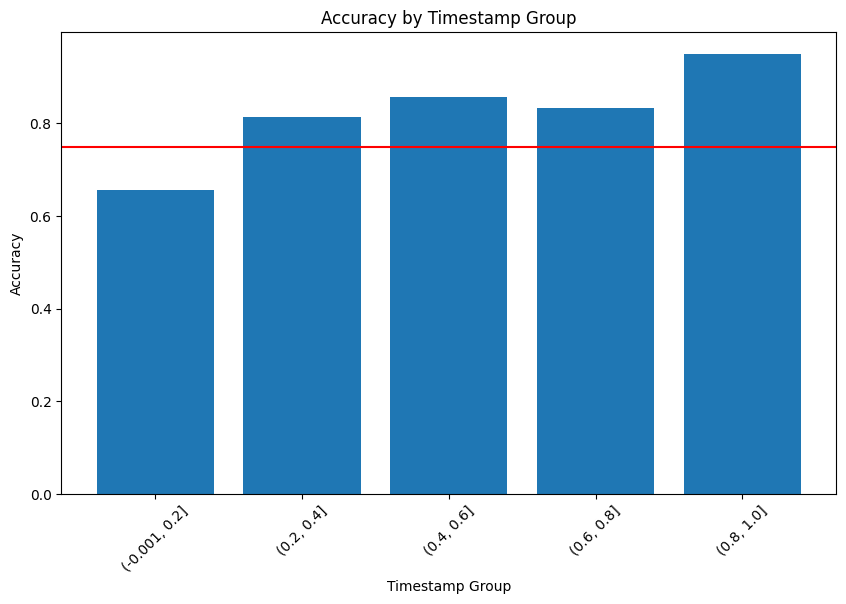

In [14]:
# Initialize an empty list to store accuracy per group
accuracy_per_group = []

# Iterate through each group and calculate accuracy
for group in y_pred_info['timestamp_group'].unique():
    subgroup = y_pred_info[y_pred_info['timestamp_group'] == group]
    # Calculate accuracy
    accuracy = accuracy_score(subgroup['y_true'], subgroup['y_pred'])
    # Append the accuracy to the list
    accuracy_per_group.append(accuracy)

accuracy_df = pd.DataFrame({
    'timestamp_group': y_pred_info['timestamp_group'].unique(),
    'accuracy': accuracy_per_group
})

# Sort the dataframe by timestamp group
accuracy_df = accuracy_df.sort_values(by='timestamp_group')

plt.figure(figsize=(10, 6))
plt.bar(accuracy_df['timestamp_group'].astype(str), accuracy_df['accuracy'])
print(mean_accuracy)
plt.axhline(y=mean_accuracy, color='r', label='Mean Accuracy')
plt.xlabel('Timestamp Group')
plt.ylabel('Accuracy')
plt.title('Accuracy by Timestamp Group')
plt.xticks(rotation=45)
plt.show()

# 4/ Fine Tuning the Model

In [15]:
"""
Hyperparameter tuning
Using GridSearchCV to find the best n_neighbors value
"""

# Define the hyperparameter grid (Number of neighbors from 1 to 20)
params = {'n_neighbors': range(1, 21)}

# Initialize GridSearchCV with cross-validation
grid_search = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    params,
    cv=5,
    verbose=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_
print(f"Optimal number of neighbors : {best_k}")
print(f"Best negative mean squared error : {best_score:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ......................................n_neighbors=1; total time= 1.4min
[CV] END ......................................n_neighbors=1; total time= 1.4min
[CV] END ......................................n_neighbors=1; total time= 1.5min
[CV] END ......................................n_neighbors=1; total time= 1.5min
[CV] END ......................................n_neighbors=1; total time= 1.5min
[CV] END ......................................n_neighbors=2; total time= 1.7min
[CV] END ......................................n_neighbors=2; total time= 1.7min
[CV] END ......................................n_neighbors=2; total time= 1.7min
[CV] END ......................................n_neighbors=2; total time= 1.7min
[CV] END ......................................n_neighbors=2; total time= 1.7min
[CV] END ......................................n_neighbors=3; total time= 1.9min
[CV] END ......................................

********** KNN SCORES **********
Mean Absolute Error (MAE): 0.3149
Mean Squared Error (MSE): 0.1637
Root Mean Squared Error (RMSE): 0.4046
R^2 Score: 0.3451
f1 Score: 0.7349
Precision Score: 0.7556
Recall Score: 0.7152
Brier Score: 0.1637
**********************************
********** KNN ACCURACY **********
Accuracy: 0.7467
**********************************


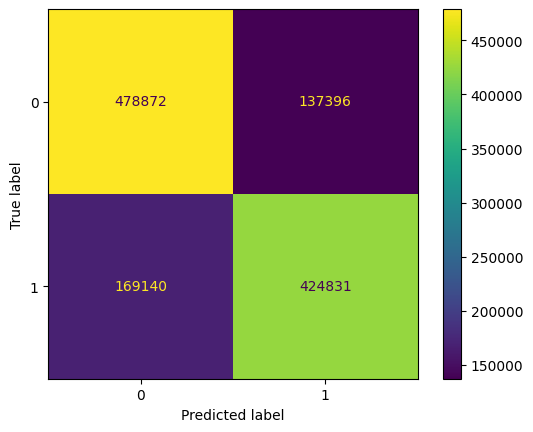

In [16]:
"""
Final Metrics for the best model
"""

# Initialize the best model
best_knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)

# Train the best model
best_knn.fit(X_train, y_train)

# Predict the entire test set
y_pred = best_knn.predict(X_test)

# Show statistics
# Evaluate the model using MAE, MSE, RMSE, R^2 Score, F1 score, Precision Score and Recall Score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
brier_score = brier_score_loss(y_test, y_pred)

# Legacy mode (convert probabilities to binary; threshold set to '> 0.5')
y_pred_binary = (y_pred > 0.5).astype(int)
f1 = f1_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)


print("********** KNN SCORES **********")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"f1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"Brier Score: {brier_score:.4f}")
print("**********************************")

# Get the final accuracy and the confusion matrix
accuracy = accuracy_score(y_test, y_pred_binary)
conf_matrix = confusion_matrix(y_test, y_pred_binary)

print("********** KNN ACCURACY **********")
print(f"Accuracy: {accuracy:.4f}")
print("**********************************")

# Plot confusion matrix
cmatrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["0", "1"])
cmatrix_display.plot() 


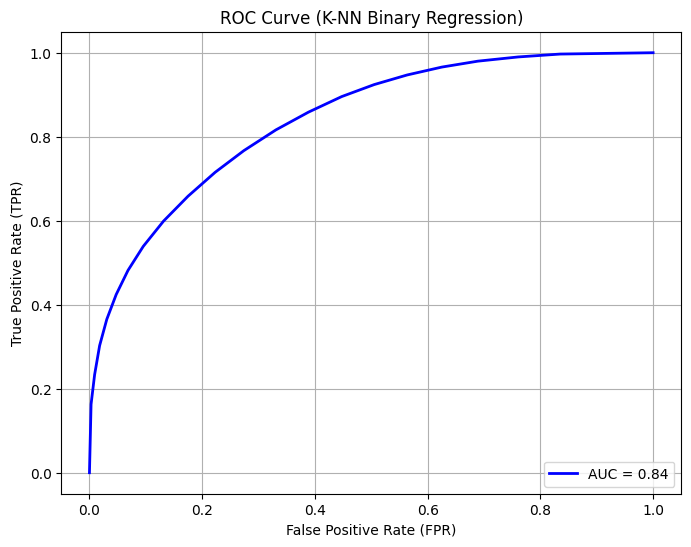

AUC-ROC Score: 0.8389


In [17]:
"""
ROC Curve & AUC-ROC Score for the best model
"""

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Compute AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_roc:.2f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (K-NN Binary Regression)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC-ROC score
print(f"AUC-ROC Score: {auc_roc:.4f}")

In [18]:
"""
Accuracy per timestamp group (5 groups)
"""

assert len(y_test_with_timestamp['timestamp']) == len(y_pred_binary) == len(y_test)

# Store each row
y_pred_info_list = []

for i in range(len(y_test_with_timestamp)):
    timestamp = y_test_with_timestamp['timestamp'].iloc[i]
    y_pred = y_pred_binary[i][0]
    y_true = y_test.iloc[i]['winner']
    y_pred_info_list.append({'timestamp': timestamp, 'y_pred': y_pred, 'y_true': y_true})

# Create a dataframe from the list
y_pred_info = pd.DataFrame(y_pred_info_list)

print(y_pred_info.head(5))

# Create timestamp groups using pd.cut
y_pred_info['timestamp_group'] = pd.cut(y_pred_info['timestamp'], bins=5)

# Store the mean accuracy (overall testing set) in "mean_accuracy"
mean_accuracy = accuracy

   timestamp  y_pred  y_true
0   0.390346       1       0
1   0.015618       1       0
2   0.000001       1       0
3   0.124945       0       0
4   0.374755       0       0


0.7467144919309326


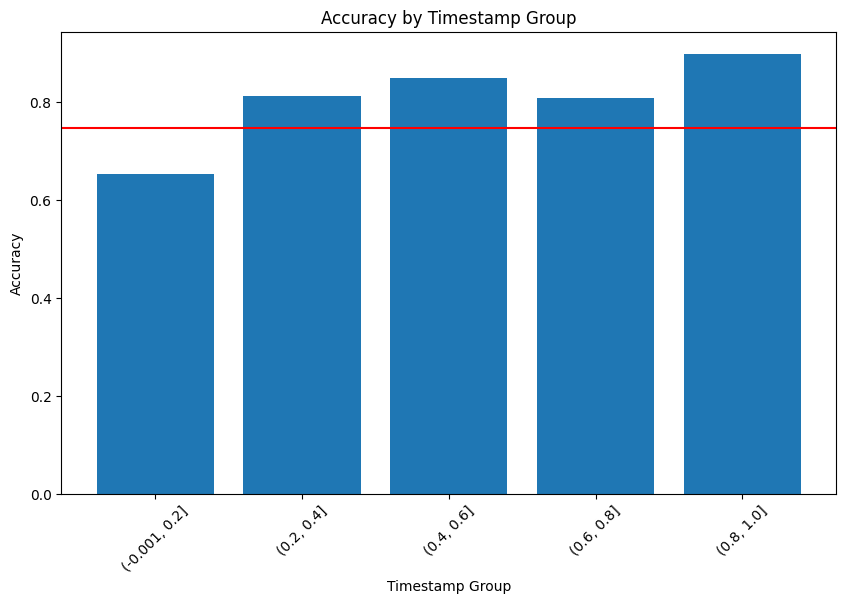

In [19]:
# Initialize an empty list to store accuracy per group
accuracy_per_group = []

# Iterate through each group and calculate accuracy
for group in y_pred_info['timestamp_group'].unique():
    subgroup = y_pred_info[y_pred_info['timestamp_group'] == group]
    # Calculate accuracy
    accuracy = accuracy_score(subgroup['y_true'], subgroup['y_pred'])
    # Append the accuracy to the list
    accuracy_per_group.append(accuracy)

accuracy_df = pd.DataFrame({
    'timestamp_group': y_pred_info['timestamp_group'].unique(),
    'accuracy': accuracy_per_group
})

# Sort the dataframe by timestamp group
accuracy_df = accuracy_df.sort_values(by='timestamp_group')

plt.figure(figsize=(10, 6))
plt.bar(accuracy_df['timestamp_group'].astype(str), accuracy_df['accuracy'])
print(mean_accuracy)
plt.axhline(y=mean_accuracy, color='r', label='Mean Accuracy')
plt.xlabel('Timestamp Group')
plt.ylabel('Accuracy')
plt.title('Accuracy by Timestamp Group')
plt.xticks(rotation=45)
plt.show()